                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Training Shape: (40000, 200)
Testing Shape : (10000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 261ms/step - accuracy: 0.8356 - loss: 0.3696 - val_accuracy: 0.8423 - val_loss: 0.3607
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 267ms/step - accuracy: 0.9087 - loss: 0.2348 - val_accuracy: 0.8919 - val_loss: 0.2902
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.9326 - loss: 0.1771 - val_accuracy: 0.8904 - val_loss: 0.2744
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 258ms/step - accuracy: 0.9465 - loss: 0.1431 - val_accuracy: 0.8904 - val_loss: 0.3043
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 271ms/step - accuracy: 0.9601 - loss: 0.1101 - val_accuracy: 0.8827 - val_loss: 0.3444
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step

Test Loss     : 0.34443750977516174
Test Accuracy : 88.27000260353088


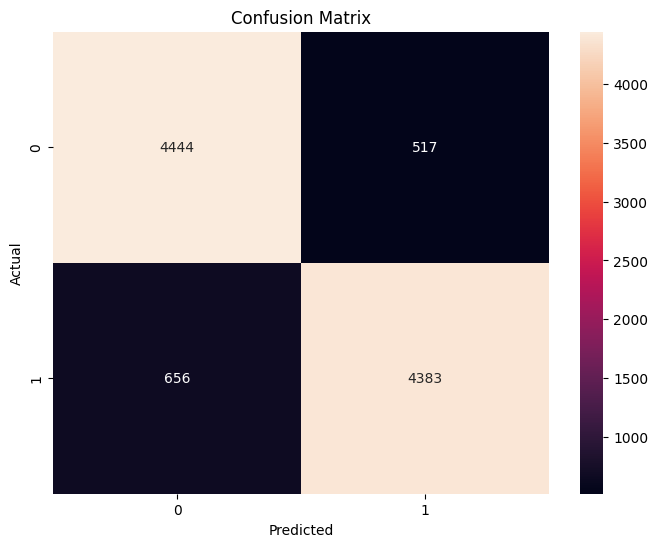


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      4961
           1       0.89      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



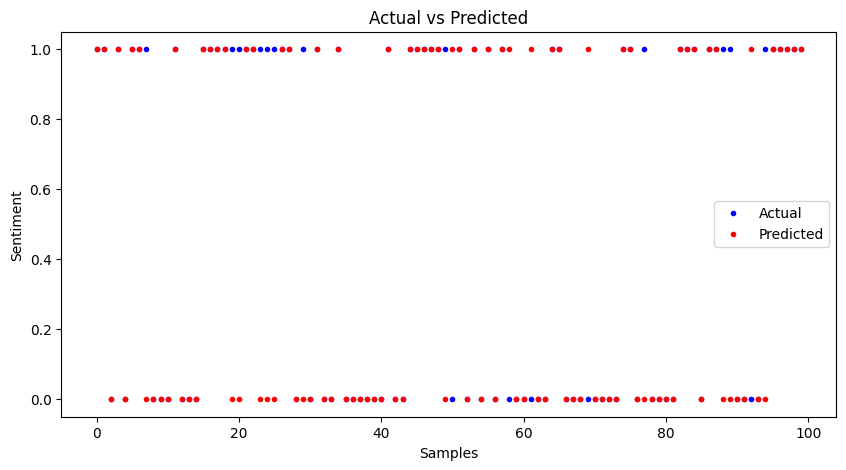

In [2]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout , Embedding ,LSTM

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# LOAD CSV DATASET
# ==============================
df = pd.read_csv(
    'IMDB Dataset.csv',
    engine='python',
    on_bad_lines='skip'
)

print(df.head())

# ==============================
# TEXT & LABELS
# ==============================
reviews = df['review'].values
sentiments = df['sentiment'].values

# Convert labels:
# positive -> 1
# negative -> 0

sentiments = np.where(sentiments == 'positive', 1, 0)

# ==============================
# TOKENIZATION
# ==============================
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)

X = pad_sequences(sequences, maxlen=max_len)

y = sentiments

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# ==============================
# MODEL
# ==============================
model = Sequential()

model.add(Embedding(10000, 128, input_length=max_len))

model.add(LSTM(64))

model.add(Dense(1, activation='sigmoid'))

# ==============================
# COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==============================
# TRAIN MODEL
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==============================
# PREDICTIONS
# ==============================
y_pred_probs = model.predict(X_test)

y_pred = (y_pred_probs > 0.5).astype(int)

# ==============================
# EVALUATION
# ==============================
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("Test Loss     :", loss)
print("Test Accuracy :", accuracy * 100)
print("==============================")

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==============================
# CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# ==============================
# ACTUAL VS PREDICTED
# ==============================
plt.figure(figsize=(10,5))

plt.plot(y_test[:100], 'b.', label='Actual')

plt.plot(y_pred[:100], 'r.', label='Predicted')

plt.title("Actual vs Predicted")

plt.xlabel("Samples")
plt.ylabel("Sentiment")

plt.legend()

plt.show()